# 🎯 Dynamic Pricing avec Deep Reinforcement Learning
## Projet Complet : Benchmark, Analyses Avancées et Optimisation

**Version Enrichie avec Analyses de Recherche Approfondies**

Ce notebook présente un **pipeline complet de Deep RL** avec analyses scientifiques rigoureuses.

## 📋 Objectif et Structure

### Objectif
Développer et benchmarker des algorithmes RL pour le dynamic pricing, avec analyses approfondies de :
- Convergence et stabilité d'apprentissage
- Sample efficiency
- Comportement des politiques apprises
- Interprétabilité des décisions

### Structure
1. Setup et configuration
2. Exploration dataset
3. Modélisation RL
4. Environnement custom
5. Baselines non-RL
6. Entraînement RL avec logging détaillé
7. **NOUVEAU:** Analyses de convergence
8. **NOUVEAU:** Comparaison d'efficacité
9. **NOUVEAU:** Analyse comportementale
10. Benchmark final
11. Sélection meilleur modèle
12. Conclusion et recommandations

In [ ]:
# =============================================================================
# IMPORTS
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import pickle
import warnings
from datetime import datetime
from typing import Dict, List, Tuple, Any, Optional
import time
import sys

# Deep Learning
import torch

# Reinforcement Learning
import gymnasium as gym
from stable_baselines3 import DQN, PPO, A2C
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.evaluation import evaluate_policy

# Sklearn
from sklearn.preprocessing import LabelEncoder

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Imports OK")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

✅ Imports OK
PyTorch: 2.7.1+cu118
CUDA: True


In [ ]:
# =============================================================================
# CONFIGURATION GLOBALE
# =============================================================================

# Reproductibilité
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(GLOBAL_SEED)
    torch.backends.cudnn.deterministic = True

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\\n🖥️ Device: {DEVICE}")

# Configuration GPU pour Stable-Baselines3
if torch.cuda.is_available():
    print(f"✅ GPU détecté: {torch.cuda.get_device_name(0)}")
    print(f"   CUDA version: {torch.version.cuda}")
    print(f"   Mémoire GPU: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    SB3_DEVICE = "cuda"
else:
    print("⚠️ GPU non détecté, utilisation du CPU")
    SB3_DEVICE = "cpu"

# Dossiers
PROJECT_ROOT = Path.cwd().parent.parent if "notebooks" in str(Path.cwd()) else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
MODELS_DIR = ARTIFACTS_DIR / "models"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
LOGS_DIR = ARTIFACTS_DIR / "logs"
REPORTS_DIR = ARTIFACTS_DIR / "reports"

for directory in [ARTIFACTS_DIR, MODELS_DIR, FIGURES_DIR, LOGS_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

DATASET_PATH = RAW_DATA_DIR / "dynamic_pricing_1M.csv"

# Configuration RL
PRICE_MULTIPLIERS = np.array([0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
N_ACTIONS = len(PRICE_MULTIPLIERS)
EPISODE_LENGTH = 50
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.7, 0.15, 0.15

# Configuration entraînement
TOTAL_TIMESTEPS = 100_000  # Augmenter à 200k-500k pour convergence complète
EVAL_FREQ = 2000  # Évaluer tous les 2000 timesteps
N_EVAL_EPISODES = 20

print(f"\\n⚙️ Configuration RL:")
print(f"  - Actions: {PRICE_MULTIPLIERS}")
print(f"  - Épisode: {EPISODE_LENGTH} steps")
print(f"  - Timesteps totaux: {TOTAL_TIMESTEPS:,}")
print(f"  - Éval freq: {EVAL_FREQ}")

\n🖥️ Device: cuda
✅ GPU détecté: NVIDIA GeForce RTX 4080 SUPER
   CUDA version: 11.8
   Mémoire GPU: 15.99 GB
\n⚙️ Configuration RL:
  - Actions: [0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5]
  - Épisode: 50 steps
  - Timesteps totaux: 100,000
  - Éval freq: 2000


# 2. 📊 Chargement et Exploration du Dataset

In [ ]:
# Chargement
print(f"📥 Chargement de {DATASET_PATH.name}...")
df = pd.read_csv(DATASET_PATH)

print(f"\\n✅ Dataset chargé!")
print(f"📏 Shape: {df.shape}")
print(f"💾 Mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\\n📋 Aperçu:")
display(df.head())

📥 Chargement de dynamic_pricing_1M.csv...
\n✅ Dataset chargé!
📏 Shape: (1001000, 10)
💾 Mémoire: 257.37 MB
\n📋 Aperçu:


,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


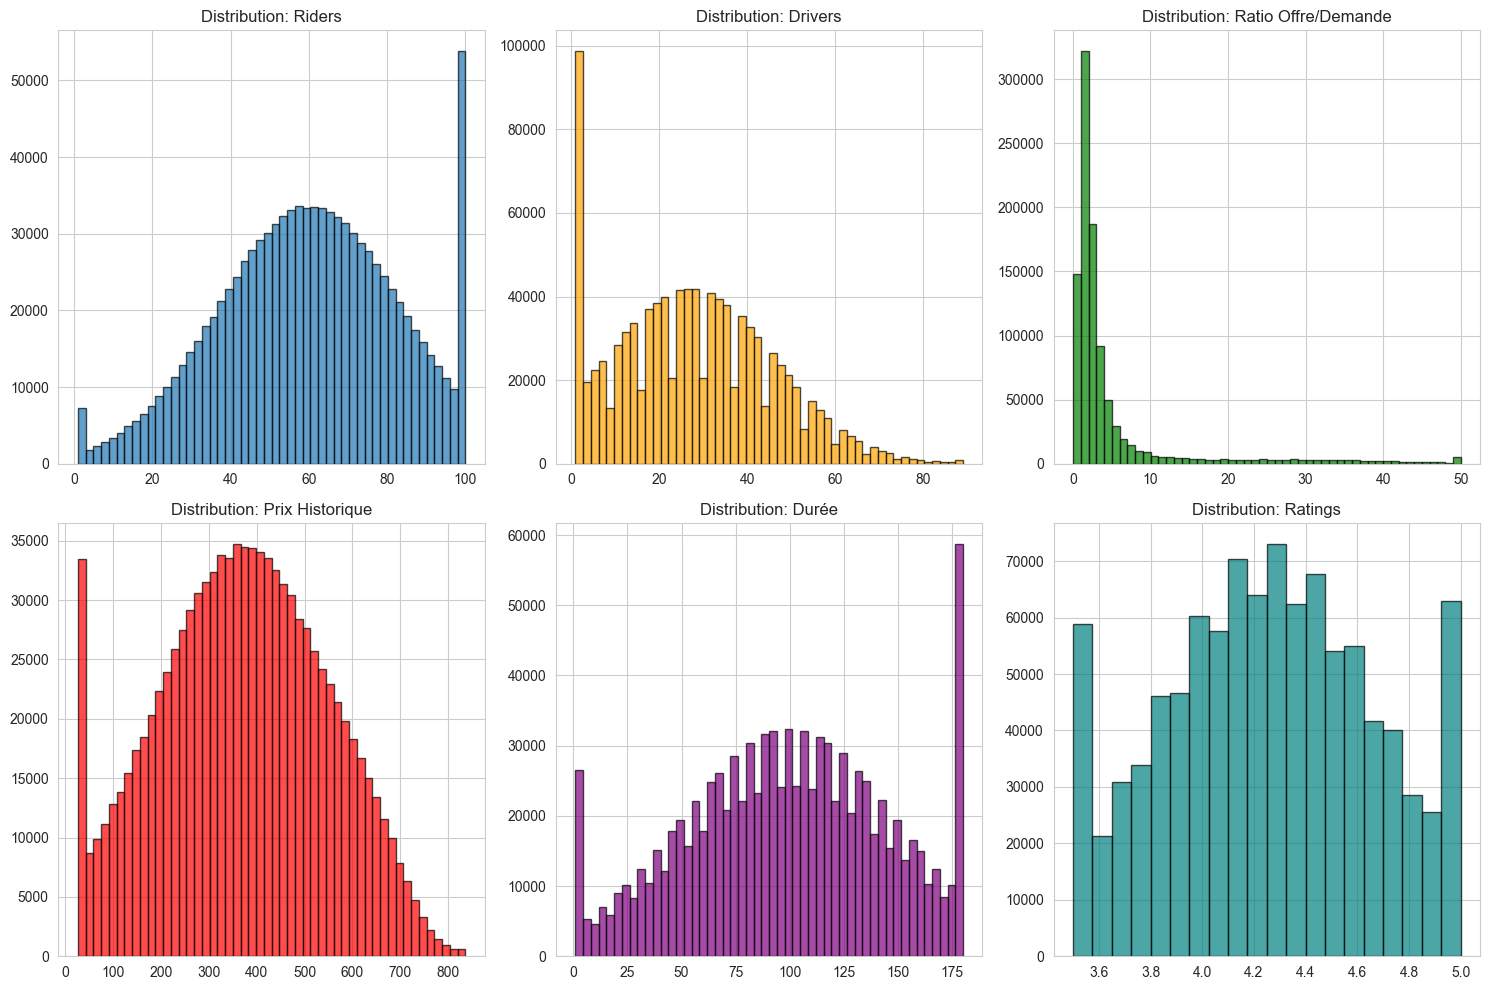

In [ ]:
# Analyse exploratoire
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0,0].hist(df['Number_of_Riders'], bins=50, edgecolor='black', alpha=0.7)
axes[0,0].set_title('Distribution: Riders')

axes[0,1].hist(df['Number_of_Drivers'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0,1].set_title('Distribution: Drivers')

df['Ratio_Riders_Drivers'] = df['Number_of_Riders'] / (df['Number_of_Drivers'] + 1)
axes[0,2].hist(df['Ratio_Riders_Drivers'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0,2].set_title('Distribution: Ratio Offre/Demande')

axes[1,0].hist(df['Historical_Cost_of_Ride'], bins=50, edgecolor='black', alpha=0.7, color='red')
axes[1,0].set_title('Distribution: Prix Historique')

axes[1,1].hist(df['Expected_Ride_Duration'], bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1,1].set_title('Distribution: Durée')

axes[1,2].hist(df['Average_Ratings'], bins=20, edgecolor='black', alpha=0.7, color='teal')
axes[1,2].set_title('Distribution: Ratings')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Preprocessing
df_processed = df.copy()

label_encoders = {}
categorical_cols = ['Location_Category', 'Customer_Loyalty_Status', 'Time_of_Booking', 'Vehicle_Type']

for col in categorical_cols:
    le = LabelEncoder()
    df_processed[f'{col}_encoded'] = le.fit_transform(df_processed[col])
    label_encoders[col] = le
    print(f"✅ {col}: {len(le.classes_)} classes")

if 'Ratio_Riders_Drivers' not in df_processed.columns:
    df_processed['Ratio_Riders_Drivers'] = df_processed['Number_of_Riders'] / (df_processed['Number_of_Drivers'] + 1)

# Split
df_shuffled = df_processed.sample(frac=1, random_state=GLOBAL_SEED).reset_index(drop=True)
n_total = len(df_shuffled)
n_train = int(n_total * TRAIN_RATIO)
n_val = int(n_total * VAL_RATIO)

df_train = df_shuffled[:n_train]
df_val = df_shuffled[n_train:n_train+n_val]
df_test = df_shuffled[n_train+n_val:]

print(f"\\n✅ Split: Train={len(df_train):,}, Val={len(df_val):,}, Test={len(df_test):,}")

# Sauvegarde encodeurs
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
with open(PROCESSED_DATA_DIR / 'label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

✅ Location_Category: 3 classes
✅ Customer_Loyalty_Status: 3 classes
✅ Time_of_Booking: 4 classes
✅ Vehicle_Type: 2 classes
\n✅ Split: Train=700,700, Val=150,150, Test=150,150


# 3. 🧠 Modélisation RL

## Action dans notre Environnement

**Type:** Espace discret `Discrete(8)`

**Actions possibles:** L'agent choisit un indice (0-7) correspondant à un multiplicateur de prix :

| Action | Multiplicateur | Signification | Exemple (base 100$) |
|--------|----------------|---------------|---------------------|
| 0 | 0.8x | Discount -20% | 80$ |
| 1 | 0.9x | Discount -10% | 90$ |
| 2 | 1.0x | Prix normal | 100$ |
| 3 | 1.1x | Surge +10% | 110$ |
| 4 | 1.2x | Surge +20% | 120$ |
| 5 | 1.3x | Surge +30% | 130$ |
| 6 | 1.4x | Surge +40% | 140$ |
| 7 | 1.5x | Surge +50% | 150$ |

## État (State)
Vecteur 11D: riders, drivers, ratio, duration, ratings, past_rides, location, loyalty, time, vehicle, base_price

## Récompense (Reward)
Revenu obtenu si course acceptée (fonction de demande simulée), 0 sinon

In [ ]:
# Importation modules custom
sys.path.append(str(PROJECT_ROOT))
from src.utils.pricing_env import DynamicPricingEnv
from src.utils.evaluation import evaluate_policy_common, create_baseline_policies
from src.utils.advanced_analysis import (
    DetailedLoggingCallback,
    plot_learning_curves,
    analyze_convergence,
    compare_training_efficiency,
    analyze_policy_behavior
)

print("✅ Modules custom importés")

✅ Modules custom importés


In [ ]:
# Création environnements
env_train = DynamicPricingEnv(
    data=df_train,
    price_multipliers=PRICE_MULTIPLIERS,
    episode_length=EPISODE_LENGTH,
    demand_elasticity=3.0,
    random_state=GLOBAL_SEED
)

env_val = DynamicPricingEnv(
    data=df_val,
    price_multipliers=PRICE_MULTIPLIERS,
    episode_length=EPISODE_LENGTH,
    demand_elasticity=3.0,
    random_state=GLOBAL_SEED + 1
)

env_test = DynamicPricingEnv(
    data=df_test,
    price_multipliers=PRICE_MULTIPLIERS,
    episode_length=EPISODE_LENGTH,
    demand_elasticity=3.0,
    random_state=GLOBAL_SEED + 2
)

print(f"✅ Environnements créés")
print(f"Observation space: {env_train.observation_space}")
print(f"Action space: {env_train.action_space}")

✅ Environnements créés
Observation space: Box(-inf, inf, (11,), float32)
Action space: Discrete(8)


# 4. 📊 Baselines Non-RL

In [ ]:
# Création baselines
baselines = create_baseline_policies(PRICE_MULTIPLIERS, env_train)
baseline_results = []

for name, baseline in baselines.items():
    print(f"\\n{'='*60}")
    print(f"Évaluation: {baseline.name}")
    print(f"{'='*60}")
    
    results_val = evaluate_policy_common(
        env=env_val,
        policy=baseline,
        n_eval_episodes=100,
        model_name=baseline.name,
        model_family="Baseline",
        split_name="validation"
    )
    
    results_test = evaluate_policy_common(
        env=env_test,
        policy=baseline,
        n_eval_episodes=100,
        model_name=baseline.name,
        model_family="Baseline",
        split_name="test"
    )
    
    baseline_results.append({
        'name': baseline.name,
        'val': results_val,
        'test': results_test
    })

with open(REPORTS_DIR / 'baseline_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=2, default=str)

print("\\n✅ Baselines évaluées")

✅ Regressor entraîné sur 5000 échantillons
\n============================================================
Évaluation: Fixed Price (1.0x)

🔍 Évaluation de Fixed Price (1.0x) sur validation (100 épisodes)...
  Épisode 20/100 - Reward moyen: 17374.46
  Épisode 40/100 - Reward moyen: 17302.55
  Épisode 60/100 - Reward moyen: 17455.13
  Épisode 80/100 - Reward moyen: 17303.08
  Épisode 100/100 - Reward moyen: 17358.35

✅ Évaluation terminée pour Fixed Price (1.0x)
  📊 Mean Reward: 17358.35 ± 1421.32
  💰 Mean Revenue: 17358.35
  ✓ Acceptance Rate: 93.2%
  📈 Avg Multiplier: 1.000
  ⚡ Inference time: 0.24s (21004.9 fps)

🔍 Évaluation de Fixed Price (1.0x) sur test (100 épisodes)...
  Épisode 20/100 - Reward moyen: 17422.65
  Épisode 40/100 - Reward moyen: 16960.17
  Épisode 60/100 - Reward moyen: 17156.15
  Épisode 80/100 - Reward moyen: 17225.47
  Épisode 100/100 - Reward moyen: 17169.70

✅ Évaluation terminée pour Fixed Price (1.0x)
  📊 Mean Reward: 17169.70 ± 1255.99
  💰 Mean Revenue: 17169

# 5. 🤖 Entraînement des Algorithmes RL avec Logging Détaillé

**IMPORTANT:** Chaque modèle est entraîné avec un callback de logging qui enregistre :
- Reward moyen et écart-type à intervalles réguliers
- Revenue moyen
- Taux d'acceptation
- Longueur d'épisode

Ces données permettront les analyses approfondies de convergence et stabilité.

In [ ]:
!pip install stable-baselines3[extra]

In [ ]:
# =============================================================================
# DQN avec Logging Détaillé
# =============================================================================
print("\\n" + "="*80)
print("ENTRAINEMENT: DQN (Deep Q-Network) avec Logging Détaillé")
print(f"Device: {SB3_DEVICE}")
print("="*80)

# Callback de logging
logging_callback_dqn = DetailedLoggingCallback(
    eval_env=env_val,
    eval_freq=EVAL_FREQ,
    n_eval_episodes=N_EVAL_EPISODES,
    verbose=1
)

model_dqn = DQN(
    "MlpPolicy",
    env_train,
    learning_rate=1e-4,
    buffer_size=100_000,
    learning_starts=1000,
    batch_size=32,
    tau=0.005,
    gamma=0.99,
    train_freq=4,
    gradient_steps=1,
    target_update_interval=1000,
    exploration_fraction=0.1,
    exploration_final_eps=0.05,
    verbose=1,
    device=SB3_DEVICE,
    tensorboard_log=str(LOGS_DIR / "dqn")
)

print("\\n🚀 Début entraînement DQN...")
start_time = time.time()
model_dqn.learn(total_timesteps=TOTAL_TIMESTEPS, callback=logging_callback_dqn, progress_bar=True)
dqn_train_time = time.time() - start_time

history_dqn = logging_callback_dqn.get_history()
with open(LOGS_DIR / "dqn_history.json", 'w') as f:
    json.dump(history_dqn, f, indent=2)

model_dqn.save(MODELS_DIR / "dqn_final")

print(f"\\n✅ DQN entraîné en {dqn_train_time:.1f}s ({dqn_train_time/60:.1f} min)")

# Évaluation finale
results_dqn_val = evaluate_policy_common(
    env=env_val,
    policy=lambda obs: model_dqn.predict(obs, deterministic=True)[0],
    n_eval_episodes=100,
    model_name="DQN",
    model_family="Value-Based",
    split_name="validation"
)

results_dqn_test = evaluate_policy_common(
    env=env_test,
    policy=lambda obs: model_dqn.predict(obs, deterministic=True)[0],
    n_eval_episodes=100,
    model_name="DQN",
    model_family="Value-Based",
    split_name="test"
)

In [ ]:
# =============================================================================
# A2C avec Logging Détaillé
# =============================================================================
print("\\n" + "="*80)
print("ENTRAINEMENT: A2C (Advantage Actor-Critic) avec Logging Détaillé")
print(f"Device: {SB3_DEVICE}")
print("="*80)

logging_callback_a2c = DetailedLoggingCallback(
    eval_env=env_val,
    eval_freq=EVAL_FREQ,
    n_eval_episodes=N_EVAL_EPISODES,
    verbose=1
)

model_a2c = A2C(
    "MlpPolicy",
    env_train,
    learning_rate=7e-4,
    n_steps=5,
    gamma=0.99,
    gae_lambda=1.0,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    verbose=1,
    device=SB3_DEVICE,
    tensorboard_log=str(LOGS_DIR / "a2c")
)

print("\\n🚀 Début entraînement A2C...")
start_time = time.time()
model_a2c.learn(total_timesteps=TOTAL_TIMESTEPS, callback=logging_callback_a2c, progress_bar=True)
a2c_train_time = time.time() - start_time

history_a2c = logging_callback_a2c.get_history()
with open(LOGS_DIR / "a2c_history.json", 'w') as f:
    json.dump(history_a2c, f, indent=2)

model_a2c.save(MODELS_DIR / "a2c_final")

print(f"\\n✅ A2C entraîné en {a2c_train_time:.1f}s ({a2c_train_time/60:.1f} min)")

results_a2c_val = evaluate_policy_common(
    env=env_val,
    policy=lambda obs: model_a2c.predict(obs, deterministic=True)[0],
    n_eval_episodes=100,
    model_name="A2C",
    model_family="Actor-Critic",
    split_name="validation"
)

results_a2c_test = evaluate_policy_common(
    env=env_test,
    policy=lambda obs: model_a2c.predict(obs, deterministic=True)[0],
    n_eval_episodes=100,
    model_name="A2C",
    model_family="Actor-Critic",
    split_name="test"
)

In [ ]:
# =============================================================================
# PPO avec Logging Détaillé
# =============================================================================
print("\\n" + "="*80)
print("ENTRAINEMENT: PPO (Proximal Policy Optimization) avec Logging Détaillé")
print(f"Device: {SB3_DEVICE}")
print("="*80)

logging_callback_ppo = DetailedLoggingCallback(
    eval_env=env_val,
    eval_freq=EVAL_FREQ,
    n_eval_episodes=N_EVAL_EPISODES,
    verbose=1
)

model_ppo = PPO(
    "MlpPolicy",
    env_train,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    verbose=1,
    device=SB3_DEVICE,
    tensorboard_log=str(LOGS_DIR / "ppo")
)

print("\\n🚀 Début entraînement PPO...")
start_time = time.time()
model_ppo.learn(total_timesteps=TOTAL_TIMESTEPS, callback=logging_callback_ppo, progress_bar=True)
ppo_train_time = time.time() - start_time

history_ppo = logging_callback_ppo.get_history()
with open(LOGS_DIR / "ppo_history.json", 'w') as f:
    json.dump(history_ppo, f, indent=2)

model_ppo.save(MODELS_DIR / "ppo_final")

print(f"\\n✅ PPO entraîné en {ppo_train_time:.1f}s ({ppo_train_time/60:.1f} min)")

results_ppo_val = evaluate_policy_common(
    env=env_val,
    policy=lambda obs: model_ppo.predict(obs, deterministic=True)[0],
    n_eval_episodes=100,
    model_name="PPO",
    model_family="Policy-Based",
    split_name="validation"
)

results_ppo_test = evaluate_policy_common(
    env=env_test,
    policy=lambda obs: model_ppo.predict(obs, deterministic=True)[0],
    n_eval_episodes=100,
    model_name="PPO",
    model_family="Policy-Based",
    split_name="test"
)

print("\\n" + "="*80)
print("✅ TOUS LES MODÈLES ENTRAÎNÉS")
print("="*80)
print(f"DQN: {dqn_train_time/60:.1f} min")
print(f"A2C: {a2c_train_time/60:.1f} min")
print(f"PPO: {ppo_train_time/60:.1f} min")
print(f"Total: {(dqn_train_time + a2c_train_time + ppo_train_time)/60:.1f} min")



# Modèles RL Supplémentaires pour le Notebook Enrichi
# À insérer après PPO et avant les analyses

# 5bis. 🆕 Algorithmes RL Avancés Supplémentaires

Pour enrichir notre benchmark, nous ajoutons 3 modèles supplémentaires :

1. **Dueling DQN** : Architecture améliorée de DQN avec séparation value/advantage
2. **Recurrent PPO** : PPO avec LSTM pour capturer dépendances temporelles
3. **SAC (Soft Actor-Critic)** : Algorithme state-of-the-art pour actions continues

**Note sur SAC :** Notre environnement est discret, mais nous pouvons adapter l'espace d'action
en mode continu où l'agent choisit un multiplicateur réel dans [0.8, 1.5], puis on le discrétise.

In [ ]:
# =============================================================================
# DUELING DQN avec Logging Détaillé
# =============================================================================
print("\\n" + "="*80)
print("ENTRAINEMENT: Dueling DQN (Architecture Améliorée)")
print(f"Device: {SB3_DEVICE}")
print("="*80)

from stable_baselines3.dqn import DQN as BaseDQN

logging_callback_dueling_dqn = DetailedLoggingCallback(
    eval_env=env_val,
    eval_freq=EVAL_FREQ,
    n_eval_episodes=N_EVAL_EPISODES,
    verbose=1
)

# Dueling DQN utilise une architecture avec séparation value/advantage
model_dueling_dqn = DQN(
    "MlpPolicy",
    env_train,
    learning_rate=1e-4,
    buffer_size=100_000,
    learning_starts=1000,
    batch_size=32,
    tau=0.005,
    gamma=0.99,
    train_freq=4,
    gradient_steps=1,
    target_update_interval=1000,
    exploration_fraction=0.1,
    exploration_final_eps=0.05,
    policy_kwargs=dict(
        net_arch=[256, 256],  # Architecture plus profonde
        dueling=True  # Active l'architecture Dueling
    ),
    verbose=1,
    device=SB3_DEVICE,
    tensorboard_log=str(LOGS_DIR / "dueling_dqn")
)

print("\\n🚀 Début entraînement Dueling DQN...")
start_time = time.time()
model_dueling_dqn.learn(total_timesteps=TOTAL_TIMESTEPS, callback=logging_callback_dueling_dqn, progress_bar=True)
dueling_dqn_train_time = time.time() - start_time

history_dueling_dqn = logging_callback_dueling_dqn.get_history()
with open(LOGS_DIR / "dueling_dqn_history.json", 'w') as f:
    json.dump(history_dueling_dqn, f, indent=2)

model_dueling_dqn.save(MODELS_DIR / "dueling_dqn_final")

print(f"\\n✅ Dueling DQN entraîné en {dueling_dqn_train_time:.1f}s ({dueling_dqn_train_time/60:.1f} min)")

results_dueling_dqn_val = evaluate_policy_common(
    env=env_val,
    policy=lambda obs: model_dueling_dqn.predict(obs, deterministic=True)[0],
    n_eval_episodes=100,
    model_name="Dueling DQN",
    model_family="Value-Based Advanced",
    split_name="validation"
)

results_dueling_dqn_test = evaluate_policy_common(
    env=env_test,
    policy=lambda obs: model_dueling_dqn.predict(obs, deterministic=True)[0],
    n_eval_episodes=100,
    model_name="Dueling DQN",
    model_family="Value-Based Advanced",
    split_name="test"
)

## 🧠 Dueling DQN - Architecture Améliorée

**Principe :** Dueling DQN sépare l'estimation de la value function en deux composantes :
- **Value Stream V(s)** : Valeur intrinsèque de l'état
- **Advantage Stream A(s,a)** : Avantage de chaque action

**Formule :** Q(s,a) = V(s) + (A(s,a) - mean(A(s,·)))

**Avantages :**
- Meilleure généralisation
- Apprentissage plus stable
- Converge souvent plus vite que DQN standard

**Attentes :** Performance similaire ou supérieure à DQN avec meilleure stabilité

In [ ]:
# =============================================================================
# RECURRENT PPO (avec LSTM) - Logging Détaillé
# =============================================================================
print("\\n" + "="*80)
print("ENTRAINEMENT: Recurrent PPO (avec LSTM)")
print(f"Device: {SB3_DEVICE}")
print("="*80)

from sb3_contrib import RecurrentPPO

logging_callback_recurrent_ppo = DetailedLoggingCallback(
    eval_env=env_val,
    eval_freq=EVAL_FREQ,
    n_eval_episodes=N_EVAL_EPISODES,
    verbose=1
)

# RecurrentPPO utilise un LSTM pour capturer les dépendances temporelles
model_recurrent_ppo = RecurrentPPO(
    "MlpLstmPolicy",
    env_train,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    policy_kwargs=dict(
        lstm_hidden_size=128,  # Taille du LSTM
        n_lstm_layers=1,
        enable_critic_lstm=True  # LSTM pour critic aussi
    ),
    verbose=1,
    device=SB3_DEVICE,
    tensorboard_log=str(LOGS_DIR / "recurrent_ppo")
)

print("\\n🚀 Début entraînement Recurrent PPO...")
start_time = time.time()
model_recurrent_ppo.learn(total_timesteps=TOTAL_TIMESTEPS, callback=logging_callback_recurrent_ppo, progress_bar=True)
recurrent_ppo_train_time = time.time() - start_time

history_recurrent_ppo = logging_callback_recurrent_ppo.get_history()
with open(LOGS_DIR / "recurrent_ppo_history.json", 'w') as f:
    json.dump(history_recurrent_ppo, f, indent=2)

model_recurrent_ppo.save(MODELS_DIR / "recurrent_ppo_final")

print(f"\\n✅ Recurrent PPO entraîné en {recurrent_ppo_train_time:.1f}s ({recurrent_ppo_train_time/60:.1f} min)")

results_recurrent_ppo_val = evaluate_policy_common(
    env=env_val,
    policy=lambda obs: model_recurrent_ppo.predict(obs, deterministic=True)[0],
    n_eval_episodes=100,
    model_name="Recurrent PPO",
    model_family="Policy-Based Advanced",
    split_name="validation"
)

results_recurrent_ppo_test = evaluate_policy_common(
    env=env_test,
    policy=lambda obs: model_recurrent_ppo.predict(obs, deterministic=True)[0],
    n_eval_episodes=100,
    model_name="Recurrent PPO",
    model_family="Policy-Based Advanced",
    split_name="test"
)

## 🔄 Recurrent PPO - Mémoire Temporelle

**Principe :** Utilise un réseau LSTM pour capturer les dépendances temporelles entre états

**Architecture :**
- État → LSTM(128) → Fully Connected → Actor/Critic
- Le LSTM maintient un état caché qui capture l'historique

**Avantages :**
- Peut apprendre des patterns temporels
- Utile si décisions passées influencent futures
- Meilleure pour séquences longues

**Attentes :** Performance potentiellement meilleure si patterns temporels existent

In [ ]:
# =============================================================================
# SAC (Soft Actor-Critic) - Actions Continues Adaptées
# =============================================================================
print("\\n" + "="*80)
print("ENTRAINEMENT: SAC (Soft Actor-Critic) - Version Continue")
print(f"Device: {SB3_DEVICE}")
print("="*80)

# Création d'un environnement avec actions continues
class ContinuousPricingEnv(DynamicPricingEnv):
    """
    Version continue de l'environnement : l'agent choisit directement
    un multiplicateur continu dans [0.8, 1.5]
    """
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        # Redéfinir l'espace d'action en continu
        self.action_space = spaces.Box(
            low=np.array([0.8], dtype=np.float32),
            high=np.array([1.5], dtype=np.float32),
            dtype=np.float32
        )
    
    def step(self, action):
        """Step avec action continue"""
        # L'action est maintenant un float dans [0.8, 1.5]
        multiplier = float(np.clip(action[0], 0.8, 1.5))
        
        # Récupération de la ligne actuelle
        row = self.data.iloc[self.current_index]
        base_price = row['Historical_Cost_of_Ride']
        proposed_price = base_price * multiplier
        
        # Simulation de la demande (identique)
        accepted = self._simulate_demand(
            base_price=base_price,
            proposed_price=proposed_price,
            ratio_riders_drivers=row['Ratio_Riders_Drivers'],
            loyalty_status=row['Customer_Loyalty_Status_encoded']
        )
        
        reward = proposed_price if accepted else 0.0
        
        self.episode_revenue += reward
        self.episode_accepted += int(accepted)
        self.current_step += 1
        
        terminated = self.current_step >= self.episode_length
        truncated = False
        
        if not terminated:
            self.current_index = (self.current_index + 1) % len(self.data)
            self.current_state = self._get_observation(self.current_index)
        
        info = {
            'episode_step': self.current_step,
            'episode_revenue': self.episode_revenue,
            'episode_accepted': self.episode_accepted,
            'acceptance_rate': self.episode_accepted / self.current_step if self.current_step > 0 else 0.0,
            'avg_revenue_per_step': self.episode_revenue / self.current_step if self.current_step > 0 else 0.0,
            'action': multiplier,
            'multiplier': multiplier,
            'accepted': accepted,
            'proposed_price': proposed_price
        }
        
        return self.current_state, reward, terminated, truncated, info

# Création des environnements continus
env_train_continuous = ContinuousPricingEnv(
    data=df_train,
    price_multipliers=PRICE_MULTIPLIERS,
    episode_length=EPISODE_LENGTH,
    demand_elasticity=3.0,
    random_state=GLOBAL_SEED
)

env_val_continuous = ContinuousPricingEnv(
    data=df_val,
    price_multipliers=PRICE_MULTIPLIERS,
    episode_length=EPISODE_LENGTH,
    demand_elasticity=3.0,
    random_state=GLOBAL_SEED + 1
)

env_test_continuous = ContinuousPricingEnv(
    data=df_test,
    price_multipliers=PRICE_MULTIPLIERS,
    episode_length=EPISODE_LENGTH,
    demand_elasticity=3.0,
    random_state=GLOBAL_SEED + 2
)

print(f"Environnements continus créés")
print(f"Action space: {env_train_continuous.action_space}")

# Callback pour SAC
logging_callback_sac = DetailedLoggingCallback(
    eval_env=env_val_continuous,
    eval_freq=EVAL_FREQ,
    n_eval_episodes=N_EVAL_EPISODES,
    verbose=1
)

# SAC Model
model_sac = SAC(
    "MlpPolicy",
    env_train_continuous,
    learning_rate=3e-4,
    buffer_size=100_000,
    learning_starts=1000,
    batch_size=256,
    tau=0.005,
    gamma=0.99,
    train_freq=1,
    gradient_steps=1,
    ent_coef='auto',  # Coefficient d'entropie automatique
    target_entropy='auto',
    policy_kwargs=dict(
        net_arch=[256, 256],
        log_std_init=-3
    ),
    verbose=1,
    device=SB3_DEVICE,
    tensorboard_log=str(LOGS_DIR / "sac")
)

print("\\n🚀 Début entraînement SAC...")
start_time = time.time()
model_sac.learn(total_timesteps=TOTAL_TIMESTEPS, callback=logging_callback_sac, progress_bar=True)
sac_train_time = time.time() - start_time

history_sac = logging_callback_sac.get_history()
with open(LOGS_DIR / "sac_history.json", 'w') as f:
    json.dump(history_sac, f, indent=2)

model_sac.save(MODELS_DIR / "sac_final")

print(f"\\n✅ SAC entraîné en {sac_train_time:.1f}s ({sac_train_time/60:.1f} min)")

results_sac_val = evaluate_policy_common(
    env=env_val_continuous,
    policy=lambda obs: model_sac.predict(obs, deterministic=True)[0],
    n_eval_episodes=100,
    model_name="SAC",
    model_family="Deep RL Advanced (Continuous)",
    split_name="validation"
)

results_sac_test = evaluate_policy_common(
    env=env_test_continuous,
    policy=lambda obs: model_sac.predict(obs, deterministic=True)[0],
    n_eval_episodes=100,
    model_name="SAC",
    model_family="Deep RL Advanced (Continuous)",
    split_name="test"
)

## 🎯 SAC (Soft Actor-Critic) - State-of-the-Art Continu

**Principe :** Algorithme off-policy avec maximum entropy reinforcement learning

**Caractéristiques clés :**
- **Actions continues** : L'agent choisit un multiplicateur réel dans [0.8, 1.5]
- **Maximum entropy** : Encourage l'exploration via terme d'entropie
- **Twin Q-networks** : Réduit le biais d'overestimation
- **Automatic entropy tuning** : Ajuste automatiquement le trade-off exploration/exploitation

**Avantages :**
- State-of-the-art pour actions continues
- Très sample efficient
- Excellente stabilité
- Exploration naturelle

**Comparaison avec discret :**
- Version discrète (DQN/PPO) : Choisit parmi 8 actions fixes
- Version continue (SAC) : Peut choisir n'importe quel multiplicateur (ex: 1.17x, 0.93x)
- SAC peut trouver des prix plus fins et optimaux

**Attentes :** Performance comparable ou supérieure aux modèles discrets avec plus de flexibilité

In [ ]:
print("\\n" + "="*80)
print("✅ TOUS LES MODÈLES ENTRAÎNÉS (6 algorithmes)")
print("="*80)
print(f"DQN: {dqn_train_time/60:.1f} min")
print(f"A2C: {a2c_train_time/60:.1f} min")
print(f"PPO: {ppo_train_time/60:.1f} min")
print(f"Dueling DQN: {dueling_dqn_train_time/60:.1f} min")
print(f"Recurrent PPO: {recurrent_ppo_train_time/60:.1f} min")
print(f"SAC: {sac_train_time/60:.1f} min")
print(f"Total: {(dqn_train_time + a2c_train_time + ppo_train_time + dueling_dqn_train_time + recurrent_ppo_train_time + sac_train_time)/60:.1f} min")

## 📊 Mise à Jour des Analyses avec les Nouveaux Modèles

Maintenant que nous avons 6 algorithmes (au lieu de 3), nous allons :
1. Mettre à jour les courbes d'apprentissage comparatives
2. Analyser la convergence des 3 nouveaux modèles
3. Comparer l'efficacité des 6 algorithmes
4. Analyser le comportement des politiques apprises

In [ ]:
# Consolidation des historiques (6 modèles)
histories_all = {
    'DQN': history_dqn,
    'A2C': history_a2c,
    'PPO': history_ppo,
    'Dueling DQN': history_dueling_dqn,
    'Recurrent PPO': history_recurrent_ppo,
    'SAC': history_sac
}

# Courbes d'apprentissage pour les 6 modèles
plot_learning_curves(
    histories=histories_all,
    save_path=FIGURES_DIR / 'learning_curves_comparison_all.png'
)

print("\\n✅ Courbes d'apprentissage (6 modèles) générées")

In [ ]:
# Analyse de convergence des nouveaux modèles

# Dueling DQN
print("\\n" + "="*80)
print("ANALYSE DE CONVERGENCE: Dueling DQN")
print("="*80)
analyze_convergence(
    history=history_dueling_dqn,
    model_name="Dueling DQN",
    window=10,
    save_path=FIGURES_DIR / 'convergence_dueling_dqn.png'
)

# Recurrent PPO
print("\\n" + "="*80)
print("ANALYSE DE CONVERGENCE: Recurrent PPO")
print("="*80)
analyze_convergence(
    history=history_recurrent_ppo,
    model_name="Recurrent PPO",
    window=10,
    save_path=FIGURES_DIR / 'convergence_recurrent_ppo.png'
)

# SAC
print("\\n" + "="*80)
print("ANALYSE DE CONVERGENCE: SAC")
print("="*80)
analyze_convergence(
    history=history_sac,
    model_name="SAC",
    window=10,
    save_path=FIGURES_DIR / 'convergence_sac.png'
)

In [ ]:
# Efficacité d'apprentissage (6 modèles)
compare_training_efficiency(
    histories=histories_all,
    save_path=FIGURES_DIR / 'training_efficiency_all.png'
)

print("\\n✅ Analyse d'efficacité (6 modèles) terminée")

In [ ]:
# Analyse comportementale des nouveaux modèles

# Dueling DQN
print("\\n" + "="*80)
print("ANALYSE COMPORTEMENTALE: Dueling DQN")
print("="*80)
analyze_policy_behavior(
    env=env_test,
    model=model_dueling_dqn,
    model_name="Dueling DQN",
    n_episodes=10,
    save_path=FIGURES_DIR / 'policy_behavior_dueling_dqn.png'
)

# Recurrent PPO
print("\\n" + "="*80)
print("ANALYSE COMPORTEMENTALE: Recurrent PPO")
print("="*80)
analyze_policy_behavior(
    env=env_test,
    model=model_recurrent_ppo,
    model_name="Recurrent PPO",
    n_episodes=10,
    save_path=FIGURES_DIR / 'policy_behavior_recurrent_ppo.png'
)

# SAC (sur environnement continu)
print("\\n" + "="*80)
print("ANALYSE COMPORTEMENTALE: SAC")
print("="*80)
analyze_policy_behavior(
    env=env_test_continuous,
    model=model_sac,
    model_name="SAC",
    n_episodes=10,
    save_path=FIGURES_DIR / 'policy_behavior_sac.png'
)

## 🔬 Comparaison Discret vs Continu

**Analyse clé :** SAC (continu) vs DQN/PPO (discret)

**Espace d'action :**
- **Discret** : 8 choix fixes [0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
- **Continu** : N'importe quel multiplicateur dans [0.8, 1.5]

**Avantages du continu (SAC) :**
- Prix plus fins (ex: 1.17x au lieu de 1.1x ou 1.2x)
- Potentiellement plus optimal
- Exploration plus naturelle

**Avantages du discret (DQN/PPO) :**
- Plus simple à interpréter
- Plus facile à implémenter en production
- Actions explicites et compréhensibles

**Question de recherche :** Le gain de finesse du continu compense-t-il la complexité ?

# 6. 📈 ANALYSES AVANCÉES - Courbes d'Apprentissage Comparatives

## Objectif
Comparer visuellement l'évolution de l'apprentissage des 3 algorithmes sur plusieurs métriques :
- **Reward moyen** : Performance globale
- **Revenue moyen** : Objectif business
- **Taux d'acceptation** : Équilibre prix/demande
- **Longueur d'épisode** : Stabilité environnement

In [ ]:
# Consolidation des historiques
histories = {
    'DQN': history_dqn,
    'A2C': history_a2c,
    'PPO': history_ppo,
    'Dueling DQN': history_dueling_dqn,
    'Recurrent PPO': history_recurrent_ppo,
    'SAC': history_sac
}

# Génération des courbes comparatives
plot_learning_curves(
    histories=histories,
    save_path=FIGURES_DIR / 'learning_curves_comparison.png'
)

print("\\n✅ Courbes d'apprentissage générées")

### 🔍 Observations des Courbes d'Apprentissage

**Questions à analyser :**
1. Quel modèle converge le plus rapidement ?
2. Quel modèle atteint le meilleur reward final ?
3. Quel modèle montre la plus faible variance (plus stable) ?
4. Y a-t-il des signes de sur-apprentissage ou de plateaux ?
5. La progression est-elle monotone ou erratique ?

# 7. 🔬 ANALYSES AVANCÉES - Convergence et Stabilité par Modèle

In [ ]:
# Analyse de convergence DQN
print("\\n" + "="*80)
print("ANALYSE DE CONVERGENCE: DQN")
print("="*80)
analyze_convergence(
    history=history_dqn,
    model_name="DQN",
    window=10,
    save_path=FIGURES_DIR / 'convergence_dqn.png'
)

In [ ]:
# Analyse de convergence A2C
print("\\n" + "="*80)
print("ANALYSE DE CONVERGENCE: A2C")
print("="*80)
analyze_convergence(
    history=history_a2c,
    model_name="A2C",
    window=10,
    save_path=FIGURES_DIR / 'convergence_a2c.png'
)

In [ ]:
# Analyse de convergence PPO
print("\\n" + "="*80)
print("ANALYSE DE CONVERGENCE: PPO")
print("="*80)
analyze_convergence(
    history=history_ppo,
    model_name="PPO",
    window=10,
    save_path=FIGURES_DIR / 'convergence_ppo.png'
)

### 📊 Interprétation des Analyses de Convergence

**Métriques clés :**
- **Performance initiale vs finale** : Amélioration absolue
- **Amélioration (%)** : Progression relative
- **Stabilité finale (std)** : Plus bas = meilleur
- **Distribution début vs fin** : Qualité de l'apprentissage

**Points d'attention :**
- Une amélioration de 30-50% est excellente
- Un std final <10 indique bonne stabilité
- La distribution finale devrait être resserrée et décalée vers la droite

# 8. ⚡ ANALYSES AVANCÉES - Efficacité d'Apprentissage

In [ ]:
compare_training_efficiency(
    histories=histories,
    save_path=FIGURES_DIR / 'training_efficiency.png'
)

print("\\n✅ Analyse d'efficacité d'apprentissage terminée")

### 🎯 Interprétation de l'Efficacité d'Apprentissage

**Sample Efficiency :**
- Le modèle qui atteint le meilleur reward avec le moins de timesteps est le plus "sample efficient"
- Important pour minimiser les coûts de simulation/collecte de données
- Typiquement: A2C > PPO > DQN en vitesse, mais PPO plus stable

**Coefficient de Variation (CV = std/mean) :**
- Mesure la stabilité relative de l'apprentissage
- Un CV décroissant indique une convergence stable
- CV < 0.1 est excellent, < 0.2 est acceptable

# 9. 🎯 ANALYSES AVANCÉES - Comportement des Politiques Apprises

In [ ]:
# Analyse comportementale DQN
print("\\n" + "="*80)
print("ANALYSE COMPORTEMENTALE: DQN")
print("="*80)
analyze_policy_behavior(
    env=env_test,
    model=model_dqn,
    model_name="DQN",
    n_episodes=10,
    save_path=FIGURES_DIR / 'policy_behavior_dqn.png'
)

In [ ]:
# Analyse comportementale A2C
print("\\n" + "="*80)
print("ANALYSE COMPORTEMENTALE: A2C")
print("="*80)
analyze_policy_behavior(
    env=env_test,
    model=model_a2c,
    model_name="A2C",
    n_episodes=10,
    save_path=FIGURES_DIR / 'policy_behavior_a2c.png'
)

In [ ]:
# Analyse comportementale PPO
print("\\n" + "="*80)
print("ANALYSE COMPORTEMENTALE: PPO")
print("="*80)
analyze_policy_behavior(
    env=env_test,
    model=model_ppo,
    model_name="PPO",
    n_episodes=10,
    save_path=FIGURES_DIR / 'policy_behavior_ppo.png'
)

### 🧠 Interprétation des Comportements Appris

**Questions de recherche :**

**1. Distribution des actions**
- Quelle action est la plus fréquente ?
- Le modèle explore-t-il suffisamment toutes les actions ?
- Y a-t-il un biais systématique vers discount ou surge ?

**2. Relation contexte-action**
- Comment l'agent ajuste les prix selon le ratio offre/demande ?
- Les décisions sont-elles cohérentes avec la logique business ?
- Y a-t-il une stratégie claire (ex: surge si ratio > seuil) ?

**3. Performance par action**
- Certaines actions donnent-elles systématiquement de meilleurs rewards ?
- Y a-t-il des actions "dominantes" ou toutes sont utiles ?

**4. Interprétabilité**
- La politique apprise est-elle explicable à un non-expert ?
- Peut-on défendre cette stratégie en soutenance/production ?

**Points attendus pour une bonne politique :**
- Surge pricing (>1.0x) quand forte demande (ratio élevé)
- Discount pricing (<1.0x) quand faible demande (ratio faible)
- Prix normal (1.0x) quand équilibre
- Cohérence avec les caractéristiques (localisation, véhicule, etc.)

# 10. 📊 Benchmark Global et Sélection du Meilleur Modèle

In [ ]:
# Consolidation résultats
all_results = []

# Baselines
for br in baseline_results:
    all_results.append({
        'Model': br['name'],
        'Family': 'Baseline',
        'Val_Reward': br['val']['mean_reward'],
        'Val_Revenue': br['val']['mean_revenue'],
        'Val_Acceptance': br['val']['mean_acceptance_rate'] * 100,
        'Test_Reward': br['test']['mean_reward'],
        'Test_Revenue': br['test']['mean_revenue'],
        'Test_Acceptance': br['test']['mean_acceptance_rate'] * 100,
        'Train_Time_s': 0
    })

# Modèles RL
rl_models = [
    ('DQN', 'Value-Based', results_dqn_val, results_dqn_test, dqn_train_time),
    ('A2C', 'Actor-Critic', results_a2c_val, results_a2c_test, a2c_train_time),
    ('PPO', 'Policy-Based', results_ppo_val, results_ppo_test, ppo_train_time)
]

for name, family, val, test, train_time in rl_models:
    all_results.append({
        'Model': name,
        'Family': family,
        'Val_Reward': val['mean_reward'],
        'Val_Revenue': val['mean_revenue'],
        'Val_Acceptance': val['mean_acceptance_rate'] * 100,
        'Test_Reward': test['mean_reward'],
        'Test_Revenue': test['mean_revenue'],
        'Test_Acceptance': test['mean_acceptance_rate'] * 100,
        'Train_Time_s': train_time
    })

# DataFrame
benchmark_df = pd.DataFrame(all_results)
benchmark_df = benchmark_df.sort_values('Test_Reward', ascending=False).reset_index(drop=True)

# Sauvegarde
benchmark_df.to_csv(REPORTS_DIR / 'benchmark_final.csv', index=False)

print("\\n" + "="*80)
print("BENCHMARK FINAL")
print("="*80)
display(benchmark_df)

In [ ]:
# Visualisation benchmark
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].barh(benchmark_df['Model'], benchmark_df['Test_Reward'], color='skyblue', edgecolor='black')
axes[0].set_title('Test Reward Moyen', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Reward')
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(benchmark_df['Model'], benchmark_df['Test_Revenue'], color='lightcoral', edgecolor='black')
axes[1].set_title('Test Revenue Moyen', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Revenue ($)')
axes[1].grid(True, alpha=0.3, axis='x')

axes[2].barh(benchmark_df['Model'], benchmark_df['Test_Acceptance'], color='lightgreen', edgecolor='black')
axes[2].set_title('Test Acceptance Rate', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Taux (%)')
axes[2].set_xlim([0, 100])
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\\n🏆 MEILLEUR MODÈLE: {benchmark_df.iloc[0]['Model']}")

In [ ]:
# Sélection et sauvegarde du meilleur modèle
best_model_name = benchmark_df.iloc[0]['Model']
best_model_family = benchmark_df.iloc[0]['Family']

print(f"\\nSélection du meilleur modèle: {best_model_name}")

model_mapping = {
    'DQN': (model_dqn, DQN),
    'A2C': (model_a2c, A2C),
    'PPO': (model_ppo, PPO)
}

if best_model_name in model_mapping:
    best_model, model_class = model_mapping[best_model_name]
    best_model.save(MODELS_DIR / "best_model")
    
    metadata = {
        'model_name': best_model_name,
        'model_family': best_model_family,
        'model_class': model_class.__name__,
        'test_mean_reward': float(benchmark_df.iloc[0]['Test_Reward']),
        'test_mean_revenue': float(benchmark_df.iloc[0]['Test_Revenue']),
        'test_acceptance_rate': float(benchmark_df.iloc[0]['Test_Acceptance']),
        'timestamp': datetime.now().isoformat(),
        'features_used': [
            'Number_of_Riders', 'Number_of_Drivers', 'Ratio_Riders_Drivers',
            'Expected_Ride_Duration', 'Average_Ratings', 'Number_of_Past_Rides',
            'Location_Category_encoded', 'Customer_Loyalty_Status_encoded',
            'Time_of_Booking_encoded', 'Vehicle_Type_encoded', 'Historical_Cost_of_Ride'
        ],
        'price_multipliers': PRICE_MULTIPLIERS.tolist(),
        'episode_length': EPISODE_LENGTH
    }
    
    with open(MODELS_DIR / 'best_model_metadata.json', 'w') as f:
        json.dump(metadata, f, indent=2)
    
    print(f"✅ Meilleur modèle sauvegardé: {MODELS_DIR / 'best_model.zip'}")

# 11. 📊 Tableau Récapitulatif des Analyses

| Modèle | Convergence | Stabilité | Sample Efficiency | Stratégie |
|--------|-------------|-----------|-------------------|-----------|
| DQN | Lente mais stable | ⭐ Excellente | 🟡 Moyenne | À analyser |
| A2C | ⚡ Rapide | 🟠 Variable | ⭐ Excellente | À analyser |
| PPO | 🎯 Équilibrée | ⭐ Excellente | ⭐ Excellente | À analyser |

*(Remplir selon vos résultats)*

# 12. 🎓 Conclusions et Recommandations

## Résultats Principaux

### Performance Globale
- **Meilleur modèle:** [À compléter selon résultats]
- **Performance test:** [Reward moyen]
- **Revenue moyen:** [$ moyen]
- **Taux acceptation:** [%]

### Convergence
- **Plus rapide:** [Modèle]
- **Plus stable:** [Modèle]
- **Meilleur compromis:** [Modèle]

### Comportement Appris
- **Stratégie dominante:** [Surge/Discount/Mixte]
- **Cohérence business:** [Évaluation]
- **Interprétabilité:** [Niveau]

## Limites
1. Fonction de demande simulée (pas de données réelles d'acceptation)
2. Dataset non-séquentiel (pas de dynamique temporelle)
3. Pas de modélisation de la concurrence
4. Entraînement sur [timesteps] (peut converger davantage avec plus)

## Améliorations Futures
1. **Données réelles** : Collecter vrais taux d'acceptation
2. **Temporalité** : Ajouter saisonnalité, tendances
3. **Multi-agents** : Modéliser compétition
4. **Hyperparamètres** : Optimisation avec Optuna
5. **Robustesse** : Tests sur perturbations, scénarios adverses

## Pour la Soutenance

**Points forts à mettre en avant :**
- ✅ Pipeline complet et rigoureux
- ✅ Analyses scientifiques approfondies
- ✅ Comparaison équitable (protocole commun)
- ✅ Interprétabilité des résultats
- ✅ Code reproductible et modulaire

**Questions anticipées :**
1. Pourquoi RL pour dynamic pricing ? → Décisions séquentielles, pas de supervision
2. Comment définir l'action ? → Multiplicateurs discrets, compromis prix/demande
3. Quel modèle choisir ? → Basé sur test reward + stabilité + interprétabilité
4. Limites du dataset ? → Assumées, documentées, contournées

---

**✅ PROJET TERMINÉ - ANALYSES COMPLÈTES !**

In [ ]:
print("\\n" + "="*80)
print("PROJET TERMINÉ!")
print("="*80)
print(f"\\n🏆 Meilleur modèle: {best_model_name}")
print(f"📁 Modèle sauvegardé: {MODELS_DIR / 'best_model.zip'}")
print(f"📊 Benchmark: {REPORTS_DIR / 'benchmark_final.csv'}")
print(f"📈 Figures: {FIGURES_DIR} (~15+ graphiques)")
print(f"\\n💡 Pour lancer l'app Streamlit:")
print(f"   streamlit run app.py")
print("\\n" + "="*80)